In [1]:
from src.performance_analysis.model_performance_analyzer import ModelPerformanceAnalyzer 
from src.training.experiment_configs import get_metadata_frames_mapping
from src.training.transforms import YTransform
import geopandas as gpd
from dotenv import load_dotenv
import os
from src.performance_analysis.model_performance_analyzer import MaskType
from hedgementation_utils.training.metadata_library import MetadataLibrary

import json
from typing import Any

from hedgementation_utils.visualization.visualization_utils import visualize_prediction
from matplotlib import pyplot as plt
import pandas as pd
import torch
from src.performance_analysis.evaluate_model import get_model_predictions
from src.training.train_utils import ModelFactory, Backbones
from src.training.trainer_config import TrainerConfig
from src.visualization.high_res_vis import get_single_prediction

from dotenv import load_dotenv
import os


from src.visualization.visualization_utils import get_and_display_prediction

load_dotenv()

DATASET_ROOT = os.environ["DATASET_ROOT"]
NUM_TILEGROUPS = int(os.environ["NUM_TILEGROUPS"])



ModuleNotFoundError: No module named 'src.preprocessing.integrate_rpg'

In [4]:
models = [
    "default",
    "medium",
    "no_cloud_filter",
]   

lib = MetadataLibrary()

metadata = lib.get_split_metadata()

analyzer = ModelPerformanceAnalyzer(
    model_directory="results",
    experiment_names=models,
    metadata_frames={"default": metadata},
    metrics=["iou", "pre", "acc",  "f1"]
)


⚡ Extracting labels from dataloader (skipping inference)...


KeyboardInterrupt: 

In [ ]:
analyzer.print_summary(experiment_names=models,   
                    gdf_names=["default"], 
                    splits=["test"],
                    metrics=["iou", "pre", "acc",  "f1"])

---------------------------------------------------------------------------------------------------------------
Experiment                                              Data     Split  iou    pre    acc    f1     Mask Type
---------------------------------------------------------------------------------------------------------------
UTAE_hedge_1.2_base                                     default  test   0.415  0.533  0.651  0.586  none     

UTAE_hedge_1.2_pretrained_PASTIS_all_layers             default  test   0.414  0.551  0.624  0.585  none     

UTAE_hedge_1.2_pretrained_PASTIS_train_out_conv_only    default  test   0.081  0.242  0.108  0.149  none     

UTAE_hedge_1.2_pretrained_PASTIS_train_last_layer_only  default  test   0.07   0.077  0.467  0.131  none     


Backbones.UTAE
torch.Size([128, 128])
torch.Size([128, 128])
Backbones.UTAE
torch.Size([128, 128])
torch.Size([128, 128])
Backbones.UTAE
torch.Size([128, 128])
torch.Size([128, 128])
Backbones.UTAE
torch.Size([128, 128])
torch.Size([128, 128])


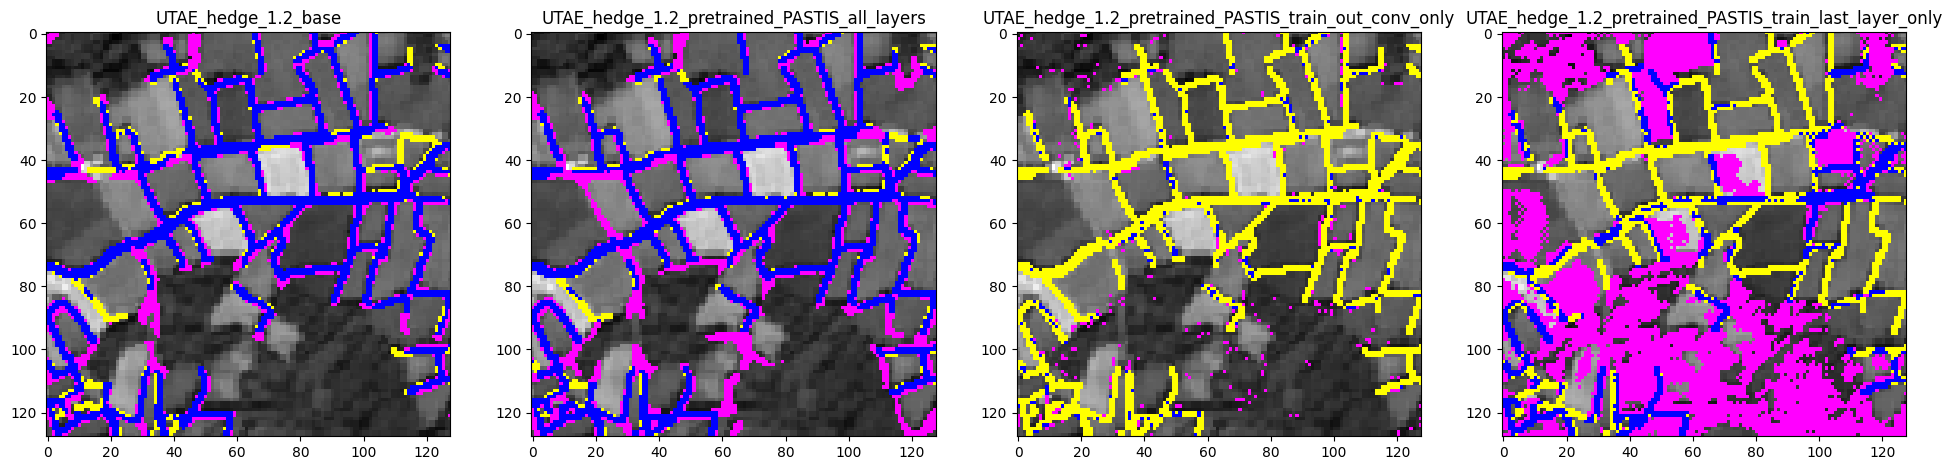

In [ ]:
fig, axs = plt.subplots(1,len(models))
fig.set_figheight(8)
fig.set_figwidth(24)

for model,ax in zip(models,axs):
    get_and_display_prediction(model, ax=ax, id=4)
    ax.set_title(model)